In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install bnlp-toolkit transformers torch xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 60.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2

In [5]:
import numpy as np
import pandas as pd
import re
import string
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

from xgboost import XGBClassifier

from transformers import AutoTokenizer, AutoModel
import torch

import joblib
import pickle

In [6]:
def clean_bangla_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'[a-zA-Z]+', '', text)
    text = re.sub(r'\d+', '', text)
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"
        u"\u3030"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub('', text)
    punctuation_to_remove = string.punctuation + '।' + '॥' + '৳' + '₹'
    text = text.translate(str.maketrans('', '', punctuation_to_remove))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/safaruzzamanshovo/stance/stance_processed.csv')  # Adjust path for Kaggle
df = df.dropna().drop_duplicates()
df['text'] = df['text'].astype(str)
df = df[df['text'].str.strip() != '']
df['cleaned_text'] = df['text'].apply(clean_bangla_text)
df = df[df['cleaned_text'].str.strip() != '']
df = df.drop_duplicates(subset=['cleaned_text'])

# Label encoding
label_map = {'pro_public': 0, 'pro_private': 1, 'neutral': 2}
reverse_label_map = {0: 'pro_public', 1: 'pro_private', 2: 'neutral'}
df['label_encoded'] = df['label'].map(label_map)
df = df.dropna(subset=['label_encoded'])

X = df['cleaned_text'].values
y = df['label_encoded'].values.astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

Dataset shape: (3364, 4)
Label distribution:
label
neutral        1403
pro_public     1038
pro_private     923
Name: count, dtype: int64


In [11]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [12]:
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")


Train size: 2691, Test size: 673


In [13]:
def get_per_class_metrics(y_true, y_pred, model_name):
    """
    Calculate per-class Precision, Recall, F1, and Accuracy
    """
    # Overall metrics
    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    # Per-class accuracy (TP / (TP + FN) for each class = recall actually)
    # But true per-class accuracy = correct predictions for class / total actual in class
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    
    results = {
        'Model': model_name,
        'Overall_Accuracy': accuracy,
        'Macro_F1': macro_f1,
        'Weighted_F1': weighted_f1
    }
    
    # Per-class metrics
    for i, class_name in reverse_label_map.items():
        results[f'{class_name}_Precision'] = precision[i]
        results[f'{class_name}_Recall'] = recall[i]
        results[f'{class_name}_F1'] = f1[i]
        results[f'{class_name}_Accuracy'] = per_class_acc[i]
        results[f'{class_name}_Support'] = support[i]
    
    return results

def print_per_class_report(y_true, y_pred, model_name):
    """Print detailed per-class report"""
    print(f"\n{'='*60}")
    print(f"MODEL: {model_name}")
    print(f"{'='*60}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, 
                                target_names=['pro_public', 'pro_private', 'neutral'],
                                digits=4))
    
    # Confusion Matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    
    # Per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    print("\nPer-Class Accuracy:")
    for i, class_name in reverse_label_map.items():
        print(f"  {class_name}: {per_class_acc[i]:.4f}")
    
    # Overall
    print(f"\nOverall Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Macro F1-Score: {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"Weighted F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")

In [14]:
# ============================================================
# 4. TF-IDF FEATURES (For Traditional ML)
# ============================================================

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF shape: {X_train_tfidf.shape}")


TF-IDF shape: (2691, 5000)


In [15]:
# Store all results
all_results = []

# ============================================================
# 5. TRADITIONAL ML MODELS
# ============================================================

# ---------- 5.1 SVM ----------
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

print_per_class_report(y_test, svm_pred, "SVM")
all_results.append(get_per_class_metrics(y_test, svm_pred, "SVM"))

# ---------- 5.2 Random Forest ----------
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=5, 
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)

print_per_class_report(y_test, rf_pred, "Random Forest")
all_results.append(get_per_class_metrics(y_test, rf_pred, "Random Forest"))

# ---------- 5.3 XGBoost ----------
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3,
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train_tfidf, y_train)
xgb_pred = xgb_model.predict(X_test_tfidf)

print_per_class_report(y_test, xgb_pred, "XGBoost")
all_results.append(get_per_class_metrics(y_test, xgb_pred, "XGBoost"))


MODEL: SVM

Classification Report:
              precision    recall  f1-score   support

  pro_public     0.9490    0.8942    0.9208       208
 pro_private     0.8670    0.8859    0.8763       184
     neutral     0.8893    0.9146    0.9018       281

    accuracy                         0.9004       673
   macro avg     0.9018    0.8982    0.8996       673
weighted avg     0.9016    0.9004    0.9007       673


Confusion Matrix:
[[186  10  12]
 [  1 163  20]
 [  9  15 257]]

Per-Class Accuracy:
  pro_public: 0.8942
  pro_private: 0.8859
  neutral: 0.9146

Overall Accuracy: 0.9004
Macro F1-Score: 0.8996
Weighted F1-Score: 0.9007

MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

  pro_public     0.9459    0.6731    0.7865       208
 pro_private     0.7379    0.5815    0.6505       184
     neutral     0.6921    0.9359    0.7958       281

    accuracy                         0.7578       673
   macro avg     0.7920    0.7302    0.7442

In [17]:

print(f"\n{'='*60}")
print("MODEL: BiLSTM")
print(f"{'='*60}")

MAX_WORDS = 10000
MAX_LEN = 100

keras_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train)

X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
X_test_seq = keras_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# BiLSTM Architecture (from paper Table II)
bilstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(128)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(bilstm_model.summary())

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_bilstm.h5', monitor='val_accuracy', save_best_only=True)

history = bilstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

bilstm_pred = bilstm_model.predict(X_test_pad)
bilstm_pred_classes = np.argmax(bilstm_pred, axis=1)

print_per_class_report(y_test, bilstm_pred_classes, "BiLSTM")
all_results.append(get_per_class_metrics(y_test, bilstm_pred_classes, "BiLSTM"))

# ============================================================
# 7. BANGLABERT + XGBOOST (BOOST POOLING)
# ============================================================

print(f"\n{'='*60}")
print("MODEL: BanglaBERT + XGBoost (Boost Pooling)")
print(f"{'='*60}")


MODEL: BiLSTM


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9000 - loss: 0.2830 - val_accuracy: 0.8815 - val_loss: 0.3222
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9746 - loss: 0.0932

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9690 - loss: 0.1052 - val_accuracy: 0.8889 - val_loss: 0.3092
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9929 - loss: 0.0342

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9905 - loss: 0.0373 - val_accuracy: 0.8926 - val_loss: 0.3388
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9954 - loss: 0.0165

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9955 - loss: 0.0125 - val_accuracy: 0.9000 - val_loss: 0.4071
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9992 - loss: 0.0033 - val_accuracy: 0.8963 - val_loss: 0.4769
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9955 - loss: 0.0109 - val_accuracy: 0.8889 - val_loss: 0.5164
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9955 - loss: 0.0124

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9967 - loss: 0.0096 - val_accuracy: 0.9111 - val_loss: 0.5280
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

MODEL: BiLSTM

Classification Report:
              precision    recall  f1-score   support

  pro_public     0.9175    0.9087    0.9130       208
 pro_private     0.8325    0.8913    0.8609       184
     neutral     0.9074    0.8719    0.8893       281

    accuracy                         0.8886       673
   macro avg     0.8858    0.8906    0.8877       673
weighted avg     0.8900    0.8886    0.8889       673


Confusion Matrix:
[[189   5  14]
 [  9 164  11]
 [  8  28 245]]

Per-Class Accuracy:
  pro_public: 0.9087
  pro_private: 0.8913
  neutral: 0.8719

Overall Accuracy: 0.8886
Macro F1-Score: 0.8877
Weighted F1-Score: 0.8889

MODEL: BanglaBERT + XGBoost (Boost Pooling)


In [18]:







# ============================================================
# 6. BiLSTM MODEL
# ============================================================




# ============================================================
# BANGLABERT SETUP - WHAT YOU NEED
# ============================================================
"""
BANGLABERT REQUIREMENTS:
------------------------
1. Model Name: "sagorsarker/bangla-bert-base"
2. Download: Auto-downloaded from HuggingFace when you run the code
3. Internet: REQUIRED for first download (enable in Kaggle)
4. GPU: Recommended for faster embedding extraction
5. Size: ~440MB model file

KAGGLE SETUP:
-------------
- Go to Kaggle notebook settings
- Enable: "Internet" ON (for downloading model)
- Enable: GPU (for faster processing)
- The model will be cached after first download

ALTERNATIVE (Offline):
----------------------
If no internet, download manually:
  wget https://huggingface.co/sagorsarker/bangla-bert-base/resolve/main/pytorch_model.bin
  wget https://huggingface.co/sagorsarker/bangla-bert-base/resolve/main/config.json
  wget https://huggingface.co/sagorsarker/bangla-bert-base/resolve/main/vocab.txt

Then load from local path:
  tokenizer = AutoTokenizer.from_pretrained('/path/to/local/model')
  model = AutoModel.from_pretrained('/path/to/local/model')
"""

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load BanglaBERT tokenizer and model
MODEL_NAME = "sagorsarker/bangla-bert-base"

print("Loading BanglaBERT tokenizer and model...")
print("This will download ~440MB on first run...")

bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
bert_model = bert_model.to(device)
bert_model.eval()

print("BanglaBERT loaded successfully!")

def get_banglabert_embeddings(texts, batch_size=16):
    """
    Extract embeddings using Boost Pooling (mean of last 4 hidden layers)
    As described in Section III-D.3 of the paper
    """
    all_embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize
        encoded = bert_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=100,
            return_tensors='pt'
        )
        
        # Move to GPU if available
        encoded = {k: v.to(device) for k, v in encoded.items()}
        
        # Forward pass
        with torch.no_grad():
            outputs = bert_model(**encoded)
        
        # Get all hidden states (13 layers: 1 embedding + 12 transformer)
        hidden_states = outputs.hidden_states
        
        # Stack last 4 layers: [4, batch, seq_len, hidden=768]
        last_4_layers = torch.stack(hidden_states[-4:])
        
        # Mean pool across 4 layers: [batch, seq_len, hidden]
        mean_pooled_layers = torch.mean(last_4_layers, dim=0)
        
        # Mean pool across sequence length: [batch, hidden]
        # Mask out padding tokens
        attention_mask = encoded['attention_mask'].unsqueeze(-1).expand(mean_pooled_layers.size())
        sum_embeddings = torch.sum(mean_pooled_layers * attention_mask, dim=1)
        sum_mask = torch.clamp(attention_mask.sum(dim=1), min=1e-9)
        sentence_embeddings = sum_embeddings / sum_mask
        
        all_embeddings.append(sentence_embeddings.cpu().numpy())
        
        # Clear cache to prevent OOM
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    return np.vstack(all_embeddings)

# Extract BanglaBERT embeddings
print("\nExtracting BanglaBERT embeddings...")
print("This may take 5-15 minutes depending on GPU...")

X_train_bert = get_banglabert_embeddings(X_train.tolist(), batch_size=16)
X_test_bert = get_banglabert_embeddings(X_test.tolist(), batch_size=16)

print(f"BERT embeddings shape: {X_train_bert.shape}")

# XGBoost on BERT embeddings (Boost Pooling)
bert_xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3,
    random_state=42, n_jobs=-1
)

bert_xgb.fit(X_train_bert, y_train)
bert_xgb_pred = bert_xgb.predict(X_test_bert)

print_per_class_report(y_test, bert_xgb_pred, "BanglaBERT + XGBoost")
all_results.append(get_per_class_metrics(y_test, bert_xgb_pred, "BanglaBERT + XGBoost"))

# ============================================================
# 8. FINAL RESULTS COMPARISON TABLE
# ============================================================

print(f"\n{'='*80}")
print("FINAL RESULTS: PER-CLASS METRICS COMPARISON")
print(f"{'='*80}")

results_df = pd.DataFrame(all_results)

# Reorder columns for better display
col_order = ['Model', 'Overall_Accuracy', 'Macro_F1', 'Weighted_F1']
for class_name in ['pro_public', 'pro_private', 'neutral']:
    col_order.extend([
        f'{class_name}_Precision',
        f'{class_name}_Recall',
        f'{class_name}_F1',
        f'{class_name}_Accuracy'
    ])
col_order.append('pro_public_Support')  # Support is same for all, just show once

results_df = results_df[col_order]

# Round to 4 decimal places
for col in results_df.columns:
    if col != 'Model' and 'Support' not in col:
        results_df[col] = results_df[col].round(4)

print("\n" + results_df.to_string(index=False))

# Save results
results_df.to_csv('stance_results_per_class.csv', index=False)
print("\nResults saved to: stance_results_per_class.csv")

# ============================================================
# 9. SAVE MODELS
# ============================================================

# Save BiLSTM
bilstm_model.save('best_stance_bilstm.h5')

# Save TF-IDF
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save Keras tokenizer
with open('keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tokenizer, f)

# Save SVM (best traditional ML usually)
joblib.dump(svm_model, 'svm_model.pkl')

# Save BanglaBERT XGBoost
joblib.dump(bert_xgb, 'banglabert_xgb_model.pkl')

print("\n" + "="*80)
print("SAVED MODELS:")
print("  - best_stance_bilstm.h5 (BiLSTM model)")
print("  - tfidf_vectorizer.pkl (TF-IDF vectorizer)")
print("  - keras_tokenizer.pkl (Keras tokenizer)")
print("  - svm_model.pkl (SVM model)")
print("  - banglabert_xgb_model.pkl (BanglaBERT+XGBoost)")
print("  - stance_results_per_class.csv (Results)")
print("="*80)

Using device: cuda
Loading BanglaBERT tokenizer and model...
This will download ~440MB on first run...


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BanglaBERT loaded successfully!

Extracting BanglaBERT embeddings...
This may take 5-15 minutes depending on GPU...
BERT embeddings shape: (2691, 768)



MODEL: BanglaBERT + XGBoost

Classification Report:
              precision    recall  f1-score   support

  pro_public     0.9648    0.9231    0.9435       208
 pro_private     0.8743    0.9076    0.8907       184
     neutral     0.9011    0.9075    0.9043       281

    accuracy                         0.9123       673
   macro avg     0.9134    0.9127    0.9128       673
weighted avg     0.9135    0.9123    0.9127       673


Confusion Matrix:
[[192   4  12]
 [  1 167  16]
 [  6  20 255]]

Per-Class Accuracy:
  pro_public: 0.9231
  pro_private: 0.9076
  neutral: 0.9075

Overall Accuracy: 0.9123
Macro F1-Score: 0.9128
Weighted F1-Score: 0.9127

FINAL RESULTS: PER-CLASS METRICS COMPARISON

               Model  Overall_Accuracy  Macro_F1  Weighted_F1  pro_public_Precision  pro_public_Recall  pro_public_F1  pro_public_Accuracy  pro_private_Precision  pro_private_Recall  pro_private_F1  pro_private_Accuracy  neutral_Precision  neutral_Recall  neutral_F1  neutral_Accuracy  pro_public_S


MODEL: BiLSTM (Heavily Regularised)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 422ms/step - accuracy: 0.8228 - loss: 0.7162 - val_accuracy: 0.8148 - val_loss: 0.7320 - learning_rate: 0.0010
Epoch 13/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.8382 - loss: 0.6678

76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 421ms/step - accuracy: 0.8183 - loss: 0.6831 - val_accuracy: 0.8296 - val_loss: 0.7199 - learning_rate: 0.0010
Epoch 14/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 421ms/step - accuracy: 0.8298 - loss: 0.6855 - val_accuracy: 0.8185 - val_loss: 0.6962 - learning_rate: 0.0010
Epoch 15/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 425ms/step - accuracy: 0.8344 - loss: 0.6521 - val_accuracy: 0.8037 - val_loss: 0.7314 - learning_rate: 0.0010
Epoch 16/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8417 - loss: 0.6751
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 429ms/step - accuracy: 0.8352 - loss: 0.6858 - val_accuracy: 0.7815 - val_loss: 0.7397 - learning_rate: 0.0010
Epoch 17/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.8553 - loss: 0.6367

76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 426ms/step - accuracy: 0.8653 - loss: 0.6244 - val_accuracy: 0.8519 - val_loss: 0.6702 - learning_rate: 5.0000e-04
Epoch 18/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 427ms/step - accuracy: 0.8740 - loss: 0.5915 - val_accuracy: 0.8333 - val_loss: 0.6548 - learning_rate: 5.0000e-04
Epoch 19/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 428ms/step - accuracy: 0.8827 - loss: 0.5753 - val_accuracy: 0.8370 - val_loss: 0.6657 - learning_rate: 5.0000e-04
Epoch 20/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 427ms/step - accuracy: 0.8781 - loss: 0.5613 - val_accuracy: 0.8333 - val_loss: 0.6538 - learning_rate: 5.0000e-04
Epoch 21/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 425ms/step - accuracy: 0.8856 - loss: 0.5701 - val_accuracy: 0.8519 - val_loss: 0.6315 - learning_rate: 5.0000e-04
Epoch 22/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.8851 - loss: 0.5512

76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 424ms/step - accuracy: 0.8806 - loss: 0.5636 - val_accuracy: 0.8704 - val_loss: 0.6127 - learning_rate: 5.0000e-04
Epoch 23/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 423ms/step - accuracy: 0.8641 - loss: 0.5789 - val_accuracy: 0.8593 - val_loss: 0.6386 - learning_rate: 5.0000e-04
Epoch 24/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8961 - loss: 0.5585
Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 425ms/step - accuracy: 0.8872 - loss: 0.5588 - val_accuracy: 0.8444 - val_loss: 0.6445 - learning_rate: 5.0000e-04
Epoch 25/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 32s 426ms/step - accuracy: 0.9054 - loss: 0.5241 - val_accuracy: 0.8519 - val_loss: 0.6234 - learning_rate: 2.5000e-04
Epoch 26/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9067 - loss: 0.5095
Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 429ms/step - accuracy: 0.9071 - l

76/76 ━━━━━━━━━━━━━━━━━━━━ 33s 432ms/step - accuracy: 0.9095 - loss: 0.5038 - val_accuracy: 0.8778 - val_loss: 0.6283 - learning_rate: 1.2500e-04


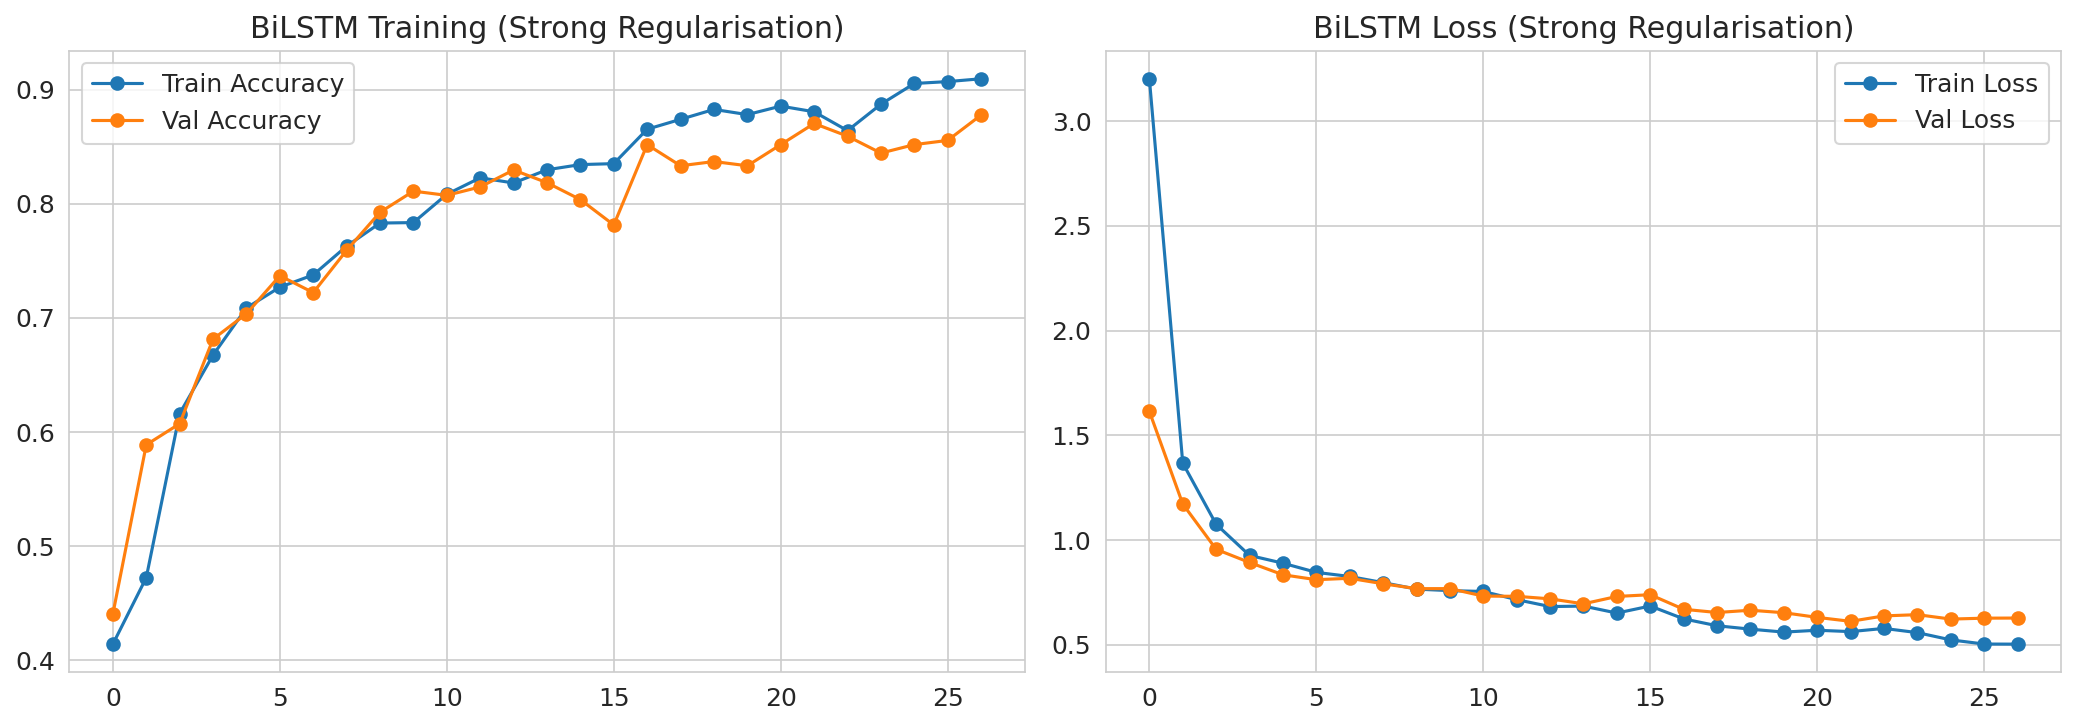

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step

MODEL: BiLSTM (Strong Reg)

Classification Report:
              precision    recall  f1-score   support

  pro_public     0.9058    0.8317    0.8672       208
 pro_private     0.6944    0.8152    0.7500       184
     neutral     0.8947    0.8470    0.8702       281

    accuracy                         0.8336       673
   macro avg     0.8316    0.8313    0.8291       673
weighted avg     0.8434    0.8336    0.8364       673


Confusion Matrix:
[[173  28   7]
 [ 13 150  21]
 [  5  38 238]]

Per-Class Accuracy:
  pro_public: 0.8317
  pro_private: 0.8152
  neutral: 0.8470

Overall Accuracy: 0.8336
Macro F1-Score: 0.8291
Weighted F1-Score: 0.8364


In [23]:
# ============================================================
# 6. BiLSTM MODEL – STRONG REGULARISATION
# ============================================================
from tensorflow.keras import regularizers

print(f"\n{'='*60}")
print("MODEL: BiLSTM (Heavily Regularised)")
print(f"{'='*60}")

MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 64
LSTM_UNITS = 32            # drastically reduced
DROPOUT_RATE = 0.6
RECURRENT_DROPOUT = 0.4
REG_L2 = 0.01

keras_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train)

X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
X_test_seq = keras_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

bilstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN,
              embeddings_regularizer=regularizers.l2(REG_L2)),
    Bidirectional(LSTM(LSTM_UNITS,
                       recurrent_dropout=RECURRENT_DROPOUT,
                       kernel_regularizer=regularizers.l2(REG_L2))),
    Dropout(DROPOUT_RATE),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(REG_L2)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

bilstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print(bilstm_model.summary())

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_bilstm.h5', monitor='val_accuracy', save_best_only=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                                 patience=2, min_lr=1e-6, verbose=1)

history = bilstm_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

# Plot training history (same as before)
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
    ax1.set_title('BiLSTM Training (Strong Regularisation)')
    ax1.legend(); ax1.grid(True)
    ax2.plot(history.history['loss'], label='Train Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Val Loss', marker='o')
    ax2.set_title('BiLSTM Loss (Strong Regularisation)')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout()
    plt.savefig('bilstm_strong_reg.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

bilstm_pred_proba = bilstm_model.predict(X_test_pad)
bilstm_pred_classes = np.argmax(bilstm_pred_proba, axis=1)

print_per_class_report(y_test, bilstm_pred_classes, "BiLSTM (Strong Reg)")
all_results.append(get_per_class_metrics(y_test, bilstm_pred_classes, "BiLSTM (Strong Reg)"))
predictions_dict["BiLSTM"] = bilstm_pred_classes